In [48]:
%matplotlib inline

In [49]:
from __future__ import annotations

In [50]:
import itertools
import typing
from pathlib import Path

import numpy as np
from scipy.signal import sawtooth
import matplotlib.pyplot as plt
from PIL import Image

if typing.TYPE_CHECKING:
    from numpy.typing import NDArray, ArrayLike

In [51]:
def plot_bitmap(
    bitmap: NDArray[np.uint8],
    dwell_time_cmap: str = "plasma",
    ax: plt.Axes | None = None,
) -> None:
    if ax is None:
        _, ax = plt.subplot(1, 1, figsize=(20, 10), squeeze=True, dpi=300)
    x_size = bitmap.shape[1]
    ax.imshow(
        bitmap[:, :, 2],
        cmap=dwell_time_cmap,
        vmin=0,
        vmax=255,
        extent=[0, x_size, 5, 10],
        interpolation="none",
        aspect="auto",
    )
    ax.imshow(
        bitmap[:, :, 1],
        cmap="Greys_r",  # reversed as 0 is blanked
        vmin=0,
        vmax=1,
        extent=[0, x_size, 0, 5],
        interpolation="none",
        aspect="auto",
    )
    ax.set_xlim(0, x_size)
    ax.set_ylim(0, 10)
    return ax


In [52]:
def tile_min_max_with_varied_spacing(
    values: ArrayLike[int],
    min_repeats: int = 1,
    max_repeats: int = 10,
    tiles: int = 3,
) -> NDArray[np.uint8]:
    arr = np.concat(
        [np.repeat(values, repeats=i) for i in range(min_repeats, max_repeats + 1)],
    ).astype(np.uint8)
    if tiles > 1:
        arr = np.tile(
            arr,
            reps=tiles,
        )
    return arr

In [71]:
def create_dwell_time_cycling_bitmap(
    min_value: int, max_pixels: int = 20, repeats: int = 3
) -> NDArray[np.uint8]:
    arr = tile_min_max_with_varied_spacing(
        (255, min_value), max_repeats=max_pixels, tiles=repeats
    )
    bitmap_arr = np.zeros((1, arr.shape[0], 3), dtype=arr.dtype)
    bitmap_arr[:, :, 1] = 1  # Set blanking off
    bitmap_arr[:, :, 2] = arr
    return bitmap_arr


In [72]:
def create_blanking_cycling_bitmap(
    min_pixels: int = 1,
    max_pixels: int = 20,
    repeats: int = 3,
    start_on: bool = True,
    dwell_time_value: int = 255,
) -> NDArray[np.uint8]:
    arr = tile_min_max_with_varied_spacing(
        (1 - int(start_on), int(start_on)),
        min_repeats=min_pixels,
        max_repeats=max_pixels,
        tiles=repeats,
    )
    bitmap_arr = np.zeros((1, arr.shape[0], 3), dtype=arr.dtype)
    bitmap_arr[:, :, 2] = dwell_time_value  # Set dwell time full
    bitmap_arr[:, :, 1] = arr
    return bitmap_arr

In [83]:
def create_wave_cycling_bitmap(
    min_value: int,
    min_cycle_pixels: int = 50,
    max_cycle_pixels: int = 550,
    cycle_pixels_step_size: int = 100,
    repeats: int = 3,
    wave_function=np.cos,
) -> NDArray[np.uint8]:
    arr = wave_function(
        [
            j
            for i in range(
                min_cycle_pixels, max_cycle_pixels + 1, cycle_pixels_step_size
            )
            for j in np.linspace(0, 2 * np.pi, endpoint=False, num=i, dtype=np.float64)
        ]
    )
    arr += 1
    arr /= 2
    arr = np.round((255 - min_value) * arr).astype(np.uint8)
    arr += min_value

    arr = np.tile(arr, reps=repeats)

    bitmap_arr = np.zeros((1, arr.shape[0], 3), dtype=arr.dtype)
    bitmap_arr[:, :, 1] = 1  # Set blanking off
    bitmap_arr[:, :, 2] = arr  # Set dwell time full
    return bitmap_arr


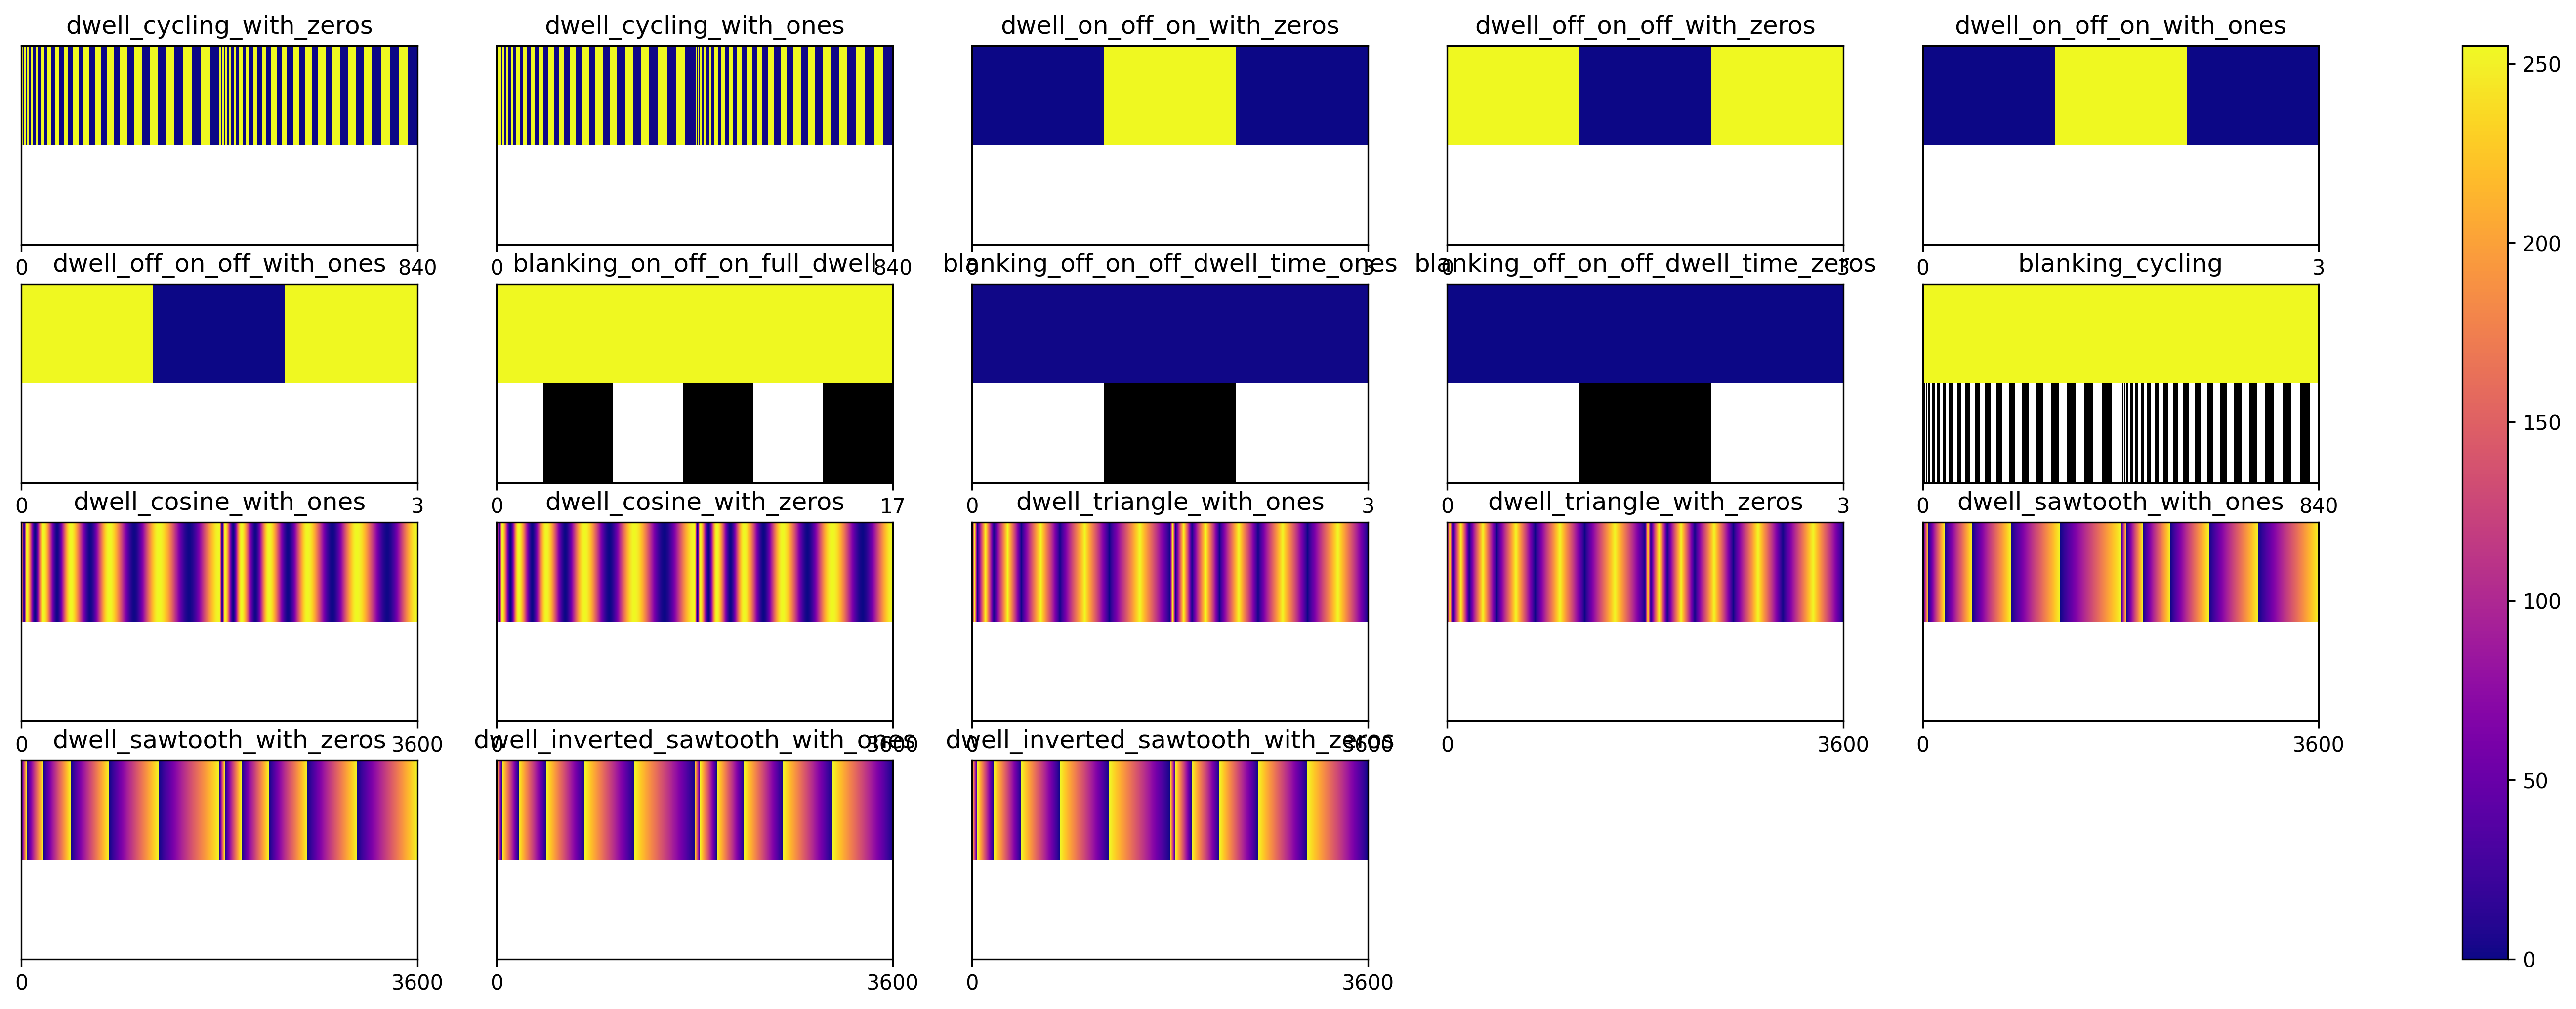

In [84]:
test_bitmaps_dir = Path.cwd().parent.parent.parent / "test_bitmaps"
test_bitmaps_dir.mkdir(exist_ok=True)

all_bitmaps: dict[str, NDArray[np.uint8]] = {
    "dwell_cycling_with_zeros": create_dwell_time_cycling_bitmap(0, repeats=2),
    "dwell_cycling_with_ones": create_dwell_time_cycling_bitmap(1, repeats=2),
    "dwell_on_off_on_with_zeros": create_dwell_time_cycling_bitmap(
        0, max_pixels=1, repeats=2
    )[:, 1:, :],
    "dwell_off_on_off_with_zeros": create_dwell_time_cycling_bitmap(
        0, max_pixels=1, repeats=2
    )[:, 0:-1, :],
    "dwell_on_off_on_with_ones": create_dwell_time_cycling_bitmap(
        0, max_pixels=1, repeats=2
    )[:, 1:, :],
    "dwell_off_on_off_with_ones": create_dwell_time_cycling_bitmap(
        0, max_pixels=1, repeats=2
    )[:, 0:-1, :],
    # "blanking_cycling_ends_blanking": create_blanking_cycling_bitmap(start_on=False),
    "blanking_on_off_on_full_dwell": create_blanking_cycling_bitmap(
        start_on=False, min_pixels=3, max_pixels=3, repeats=3
    )[:, 1:, :],
    "blanking_off_on_off_dwell_time_ones": create_blanking_cycling_bitmap(
        start_on=True, max_pixels=1, repeats=2, dwell_time_value=1
    )[:, 1:, :],
    "blanking_off_on_off_dwell_time_zeros": create_blanking_cycling_bitmap(
        start_on=True, max_pixels=1, repeats=2, dwell_time_value=0
    )[:, 1:, :],
    "blanking_cycling": create_blanking_cycling_bitmap(start_on=True, repeats=2),
    # "blanking_vs_low_dwell_time_ones": create_blanking_cycling_bitmap(
    #     min_pixels=3, max_pixels=3, dwell_time_value=1
    # ),
    # "blanking_vs_low_dwell_time_zeros": create_blanking_cycling_bitmap(
    #     min_pixels=3, max_pixels=3, dwell_time_value=0
    # ),
    "dwell_cosine_with_ones": create_wave_cycling_bitmap(1, repeats=2),
    "dwell_cosine_with_zeros": create_wave_cycling_bitmap(0, repeats=2),
    "dwell_triangle_with_ones": create_wave_cycling_bitmap(
        1, repeats=2, wave_function=lambda x: sawtooth(x, width=0.5)
    ),
    "dwell_triangle_with_zeros": create_wave_cycling_bitmap(
        0, repeats=2, wave_function=lambda x: sawtooth(x, width=0.5)
    ),
    "dwell_sawtooth_with_ones": create_wave_cycling_bitmap(
        1, repeats=2, wave_function=sawtooth
    ),
    "dwell_sawtooth_with_zeros": create_wave_cycling_bitmap(
        0, repeats=2, wave_function=sawtooth
    ),
    "dwell_inverted_sawtooth_with_ones": create_wave_cycling_bitmap(
        1, repeats=2, wave_function=lambda x: sawtooth(x, width=0)
    ),
    "dwell_inverted_sawtooth_with_zeros": create_wave_cycling_bitmap(
        0, repeats=2, wave_function=lambda x: sawtooth(x, width=0)
    ),
}

num_bitmaps = len(all_bitmaps)
nrows = int(np.round(np.sqrt(len(all_bitmaps))))
ncols = int(np.ceil(num_bitmaps / nrows))
fig, axs = plt.subplots(
    nrows,
    ncols,
    # sharex=True,
    sharey=True,
    squeeze=True,
    figsize=(5 * ncols, 2 * nrows),
    dpi=300,
)
dwell_time_cmap = "plasma"

# Create colourbar for all plots
im = axs.flat[0].imshow(((0, 255),), vmin=0, vmax=255, cmap=dwell_time_cmap)
fig.colorbar(im, ax=axs.ravel().tolist())

axs.flat[0].clear()

for ax, bitmap_info in itertools.zip_longest(axs.flat, all_bitmaps.items()):
    if bitmap_info is None:
        ax.set_axis_off()
    else:
        name, bitmap = bitmap_info

        ax.set_title(name)
        ax.set_xticks([0, bitmap.shape[1]])
        ax.set_yticks([])

        plot_bitmap(bitmap, dwell_time_cmap, ax=ax)
        fig.canvas.draw()
        handles, labels = ax.get_legend_handles_labels()

        Image.fromarray(bitmap).save(test_bitmaps_dir / f"{name}.bmp", format="BMP")
        Image.fromarray(np.tile(bitmap, (2, 1, 1))).save(
            test_bitmaps_dir / f"{name}_2d.bmp", format="BMP"
        )


fig.savefig(test_bitmaps_dir / "bitmap_summary.png")
fig.canvas.draw()
